MAE : 0.887
RMSE: 0.994
R2  : -0.005


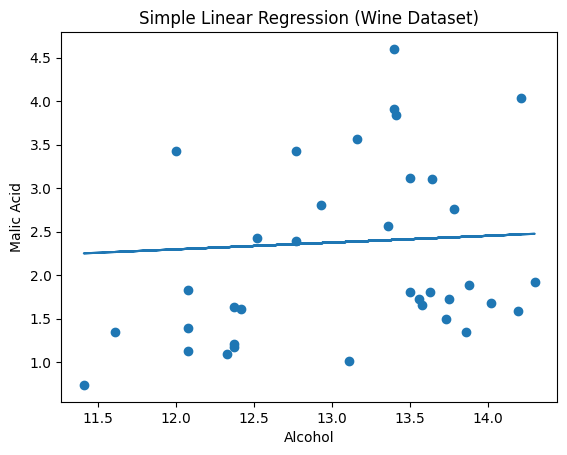

In [1]:
# ============================================
# TUGAS 1 - SIMPLE LINEAR REGRESSION
# Dataset: Wine
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------
# 1. Load Dataset
# ------------------------------
data = load_wine(as_frame=True)
df = data.frame

# Gunakan 1 fitur (alcohol)
X = df[["alcohol"]]
y = df["malic_acid"]

# ------------------------------
# 2. Split Data (80:20)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 3. Train Model
# ------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------
# 4. Prediksi
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# 5. Evaluasi Model
# ------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R2  :", round(r2,3))

# ------------------------------
# 6. Visualisasi Garis Regresi
# ------------------------------
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Simple Linear Regression (Wine Dataset)")
plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.show()

In [2]:
# ============================================
# TUGAS 2 - MULTIPLE LINEAR REGRESSION
# Dataset: Wine
# ============================================

# ------------------------------
# 1. Load Dataset
# ------------------------------
data = load_wine(as_frame=True)
df = data.frame

# ------------------------------
# 2. Gunakan minimal 3 fitur
# ------------------------------
X_multi = df[["alcohol", "malic_acid", "ash"]]
y_multi = df["proline"]

# ------------------------------
# 3. Split Data (80:20)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

# ------------------------------
# 6. Evaluasi Model
# ------------------------------
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("\n=== MULTIPLE LINEAR REGRESSION ===")
print("MAE :", round(mae_multi,3))
print("RMSE:", round(rmse_multi,3))
print("R2  :", round(r2_multi,3))


=== MULTIPLE LINEAR REGRESSION ===
MAE : 188.931
RMSE: 238.545
R2  : 0.551


In [3]:
print("\n=== Tugas 3: Bandingkan degree 1 vs 2 ===")

from sklearn.datasets import load_wine
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset Wine
data = load_wine(as_frame=True)
df = data.frame

# Gunakan 1 fitur untuk regresi
X = df[["alcohol"]]
y = df["malic_acid"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Degree 1 (linear)
X_train_d1 = X_train[[X.columns[0]]]
X_test_d1 = X_test[[X.columns[0]]]

model_d1 = LinearRegression().fit(X_train_d1, y_train)

# Degree 2 (polynomial)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression().fit(X_train_poly, y_train)

# Hasil perbandingan
print(f"Degree 1 R2: {round(model_d1.score(X_test_d1, y_test), 3)}")
print(f"Degree 2 R2: {round(poly_model.score(X_test_poly, y_test), 3)}")

print("→ Degree 2 menangkap pola non-linear sehingga R2 bisa lebih tinggi.")


=== Tugas 3: Bandingkan degree 1 vs 2 ===
Degree 1 R2: -0.005
Degree 2 R2: 0.052
→ Degree 2 menangkap pola non-linear sehingga R2 bisa lebih tinggi.


In [4]:
print("\n=== Tugas 4: Metrik Lengkap (MAE, RMSE, R²) ===")

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Prediksi menggunakan model polynomial degree 2
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluasi model
print("MAE :", round(mean_absolute_error(y_test, y_pred_poly), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_poly), 3))
print("R2  :", round(r2_score(y_test, y_pred_poly), 3))


=== Tugas 4: Metrik Lengkap (MAE, RMSE, R²) ===
MAE : 0.851
RMSE: 0.966
R2  : 0.052
